# Lab 2 — ML Primitives in NumPy

Run this notebook top to bottom as you build out `knn.py`, `gradient_descent.py`, and `pca.py` in this same folder. Each section below is a placeholder — see `Lab2_Instructions.md` for what belongs in each cell.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the data generation, plotting, and test calls are yours to write.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from knn import knn_predict, predict_grid, euclidean_distance, cosine_similarity
from gradient_descent import f, grad_f, gradient_descent_1d, f2, grad_f2, gradient_descent_2d
from pca import pca_via_svd

## Part A: k-NN Classifier

In [11]:
# generating a small 2-class training set (X_train, y_train)
np.random.seed(0)
class0 = np.random.randn(30,2)

class1 = np.random.randn(30,2)+3

X_train = np.vstack((class0,class1))

y_train = np.array([0]*30+[1]*30)

k=3


In [3]:
print(X_train)
print(y_train)

[[ 3.76405235  2.40015721]
 [ 2.97873798  4.2408932 ]
 [ 3.86755799  1.02272212]
 [ 2.95008842  1.84864279]
 [ 1.89678115  2.4105985 ]
 [ 2.14404357  3.45427351]
 [ 2.76103773  2.12167502]
 [ 2.44386323  2.33367433]
 [ 3.49407907  1.79484174]
 [ 2.3130677   1.14590426]
 [-0.55298982  2.6536186 ]
 [ 2.8644362   1.25783498]
 [ 4.26975462  0.54563433]
 [ 2.04575852  1.81281615]
 [ 3.53277921  3.46935877]
 [ 2.15494743  2.37816252]
 [ 1.11221425  0.01920353]
 [ 1.65208785  2.15634897]
 [ 3.23029068  3.20237985]
 [ 1.61267318  1.69769725]
 [ 0.95144703  0.57998206]
 [ 0.29372981  3.9507754 ]
 [ 1.49034782  1.5619257 ]
 [ 0.74720464  2.77749036]
 [ 0.38610215  1.78725972]
 [ 1.10453344  2.3869025 ]
 [ 1.48919486  0.81936782]
 [ 1.97181777  2.42833187]
 [ 2.06651722  2.3024719 ]
 [ 1.36567791  1.63725883]
 [-2.67246045 -2.35955316]
 [-2.81314628 -3.7262826 ]
 [-1.82257386 -2.40178094]
 [-3.63019835 -1.53721774]
 [-2.90729836 -1.9480546 ]
 [-1.27090944 -1.87101709]
 [-0.86059932 -3.23482582]
 

In [13]:
# TODO: pick a query point and call knn_predict to classify it
query = np.array([0, 0])

prediction = knn_predict(query, X_train, y_train, k)

print("Query Point :", query)
print("Predicted Class :", prediction)

Query Point : [0 0]
Predicted Class : 0


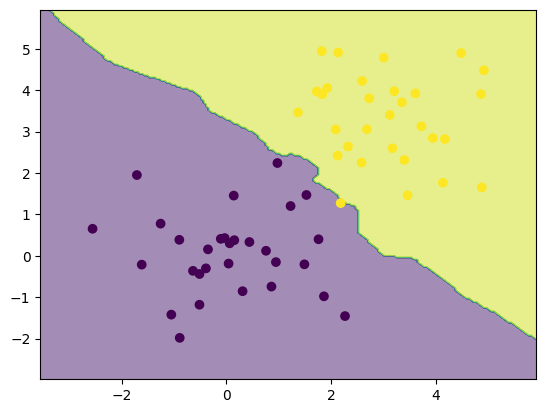

In [15]:
# TODO: build a meshgrid over the training data's range, classify every grid point,
# and plot the decision boundary with contourf (don't forget to reshape predictions to xx.shape)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
predictions = predict_grid(grid, X_train, y_train, k=3)
Z = predictions.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis")
plt.savefig(
    "plots/knn_decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part B: Gradient Descent

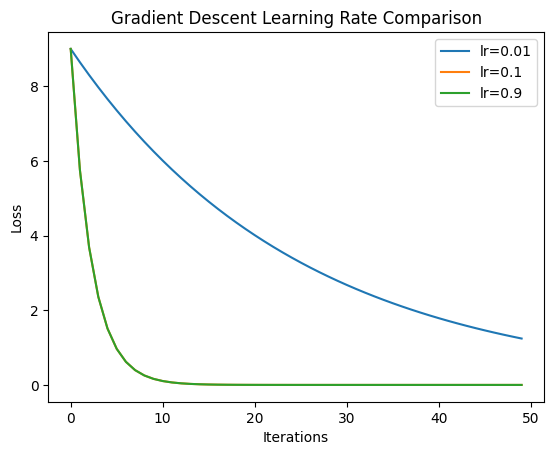

In [19]:
# TODO: run gradient_descent_1d with at least three learning rates and plot loss vs. iteration for each
# (include at least one learning rate that visibly diverges or oscillates)
lrs = [0.01, 0.1, 0.9]
for lr in lrs:
    x_final, history = gradient_descent_1d(start=0.0, lr=lr, steps=50)
    losses = np.array([f(x) for x in history])
    plt.plot(range(len(losses)), losses, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Gradient Descent Learning Rate Comparison")
plt.legend()

plt.savefig(
    "plots/gd_learning_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

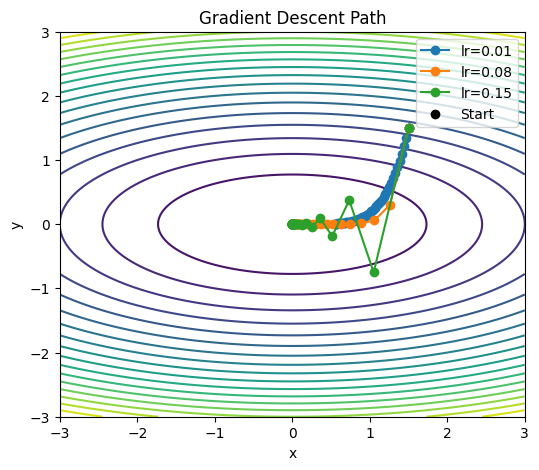

In [30]:
x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 5*Y**2
plt.figure(figsize=(6,5))

plt.contour(X, Y, Z, levels=20)

start_point = (1.5,1.5)

for lr in [0.01, 0.08, 0.15]:

    final_point, path = gradient_descent_2d(
        start_point,
        lr,
        50
    )

    plt.plot(path[:,0],
             path[:,1],
             marker='o',
             label=f"lr={lr}")

plt.scatter(start_point[0],
            start_point[1],
            color='black',
            label="Start")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Path")
plt.legend()

plt.savefig("plots/gd_2d_path.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Part C: PCA Via SVD

In [31]:
# TODO: generate a 2D dataset with an obvious principal direction (e.g. y = 2x + noise)
np.random.seed(0)

x = np.random.randn(100)

y = 2*x + np.random.randn(100)*0.5

data = np.column_stack((x,y))

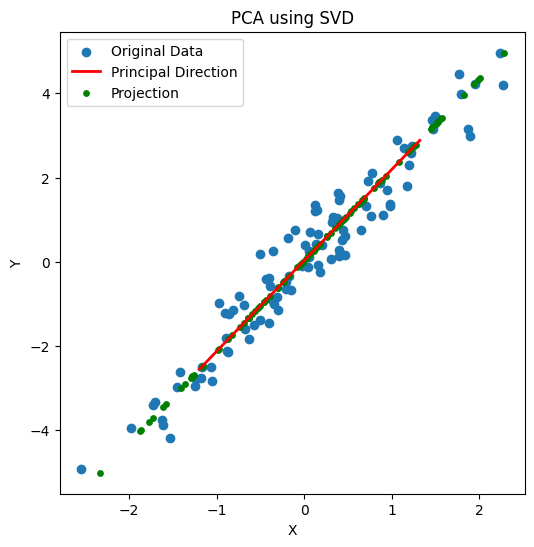

In [33]:
# TODO: call pca_via_svd, then plot the original (centered) data, the principal direction,
# and the projection together on one chart
projected, components = pca_via_svd(data,1)
center = data.mean(axis=0)
direction = components[0]

plt.figure(figsize=(6,6))

plt.scatter(data[:,0],
            data[:,1],
            label="Original Data")

t = np.linspace(-3,3,100)

line = center + np.outer(t,direction)

plt.plot(line[:,0],
         line[:,1],
         color="red",
         linewidth=2,
         label="Principal Direction")

projected_points = projected @ components + center

plt.scatter(projected_points[:,0],
            projected_points[:,1],
            color="green",
            s=15,
            label="Projection")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA using SVD")
plt.legend()

plt.savefig("plots/pca_svd.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
